# Formula 1 Lap Time Analysis

Exploratory data analysis and XGBoost modeling of **2024 Formula 1 lap times** using FastF1.

### Analysis workflow
1. Load and inspect 2024 Bahrain qualifying data
2. Explore lap times, compounds, sectors, and speed traps
3. Build and evaluate an XGBoost lap-time model
4. Compare predictions with and without sector times
5. Combine qualifying and race data
6. Expand the dataset across four circuits
7. Analyze tyre degradation and track evolution
8. Measure driver consistency across circuits

## 1. Setup and Data Loading

In [1]:
import fastf1
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import yellowbrick
import sklearn
import xgboost as xgb

print("All imports OK")
print("FastF1 version:", fastf1.__version__)

All imports OK
FastF1 version: 3.8.3


In [2]:
import os

cache_dir = "f1_cache"
os.makedirs(cache_dir, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)

print("Cache ready at:", os.path.abspath(cache_dir))

Cache ready at: D:\projects\F1story\f1_cache


In [3]:
session = fastf1.get_session(2024, 'Bahrain', 'Q')
session.load()

print(session.results[['FullName', 'TeamName', 'Q1', 'Q2', 'Q3']].head(10))
print("\nLaps shape:", session.laps.shape)
print(session.laps.columns.tolist())

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']


           FullName         TeamName                     Q1  \
1    Max Verstappen  Red Bull Racing 0 days 00:01:30.031000   
16  Charles Leclerc          Ferrari 0 days 00:01:30.243000   
63   George Russell         Mercedes 0 days 00:01:30.350000   
55     Carlos Sainz          Ferrari 0 days 00:01:29.909000   
11     Sergio Perez  Red Bull Racing 0 days 00:01:30.221000   
14  Fernando Alonso     Aston Martin 0 days 00:01:30.179000   
4      Lando Norris          McLaren 0 days 00:01:30.143000   
81    Oscar Piastri          McLaren 0 days 00:01:30.531000   
44   Lewis Hamilton         Mercedes 0 days 00:01:30.451000   
27  Nico Hulkenberg     Haas F1 Team 0 days 00:01:30.566000   

                       Q2                     Q3  
1  0 days 00:01:29.374000 0 days 00:01:29.179000  
16 0 days 00:01:29.165000 0 days 00:01:29.407000  
63 0 days 00:01:29.922000 0 days 00:01:29.485000  
55 0 days 00:01:29.573000 0 days 00:01:29.507000  
11 0 days 00:01:29.932000 0 days 00:01:29.537000  


In [4]:
# Filter to accurate laps only — deleted/outliers skew everything
clean_laps = session.laps.pick_accurate()

print("Clean laps:", len(clean_laps))
print("\nLap time stats:")
print(clean_laps['LapTime'].describe())

Clean laps: 85

Lap time stats:
count                           85
mean        0 days 00:01:30.379200
std      0 days 00:00:00.638536828
min         0 days 00:01:29.165000
25%         0 days 00:01:29.922000
50%         0 days 00:01:30.425000
75%         0 days 00:01:30.793000
max         0 days 00:01:32.434000
Name: LapTime, dtype: object


## 2. Exploratory Data Analysis — Bahrain Qualifying

### Lap-time distributions

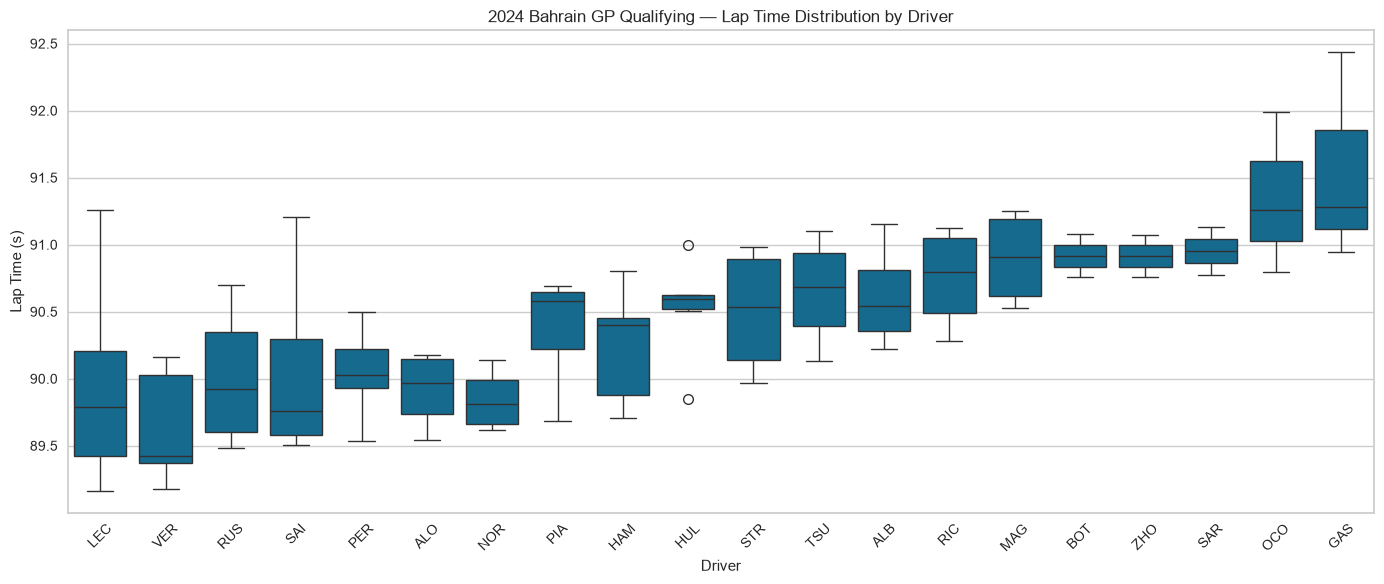

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert LapTime to seconds for plotting
clean_laps = clean_laps.copy()
clean_laps['LapTimeSeconds'] = clean_laps['LapTime'].dt.total_seconds()

plt.figure(figsize=(14, 6))
sns.boxplot(data=clean_laps, x='Driver', y='LapTimeSeconds', order=clean_laps.groupby('Driver')['LapTimeSeconds'].min().sort_values().index)
plt.title('2024 Bahrain GP Qualifying — Lap Time Distribution by Driver')
plt.xlabel('Driver')
plt.ylabel('Lap Time (s)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

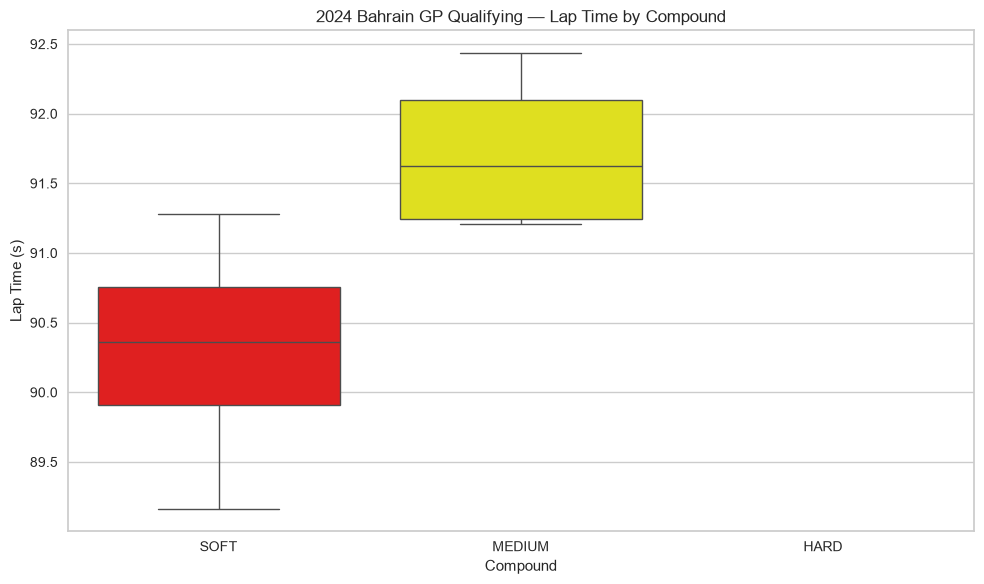

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=clean_laps, x='Compound', y='LapTimeSeconds',
            hue='Compound', legend=False,
            order=['SOFT', 'MEDIUM', 'HARD'],
            palette={'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white'})
plt.title('2024 Bahrain GP Qualifying — Lap Time by Compound')
plt.xlabel('Compound')
plt.ylabel('Lap Time (s)')
plt.tight_layout()
plt.show()

In [7]:
print(clean_laps['Compound'].value_counts())

Compound
SOFT      81
MEDIUM     4
Name: count, dtype: int64


### Best lap and sector performance

In [8]:
# Best lap per driver
best_laps = clean_laps.loc[clean_laps.groupby('Driver')['LapTimeSeconds'].idxmin()].copy()

best_laps['S1'] = best_laps['Sector1Time'].dt.total_seconds()
best_laps['S2'] = best_laps['Sector2Time'].dt.total_seconds()
best_laps['S3'] = best_laps['Sector3Time'].dt.total_seconds()

# Sort by total lap time
best_laps = best_laps.sort_values('LapTimeSeconds')

print(best_laps[['Driver', 'S1', 'S2', 'S3', 'LapTimeSeconds']].to_string(index=False))

Driver     S1     S2     S3  LapTimeSeconds
   LEC 28.843 38.059 22.263          89.165
   VER 28.535 38.269 22.375          89.179
   RUS 28.800 38.421 22.264          89.485
   SAI 28.850 38.298 22.359          89.507
   PER 28.804 38.323 22.410          89.537
   ALO 28.830 38.236 22.476          89.542
   NOR 29.045 38.207 22.362          89.614
   PIA 28.901 38.343 22.439          89.683
   HAM 28.881 38.422 22.407          89.710
   HUL 28.834 38.636 22.381          89.851
   STR 28.651 38.609 22.705          89.965
   TSU 28.821 38.727 22.581          90.129
   ALB 28.866 38.802 22.553          90.221
   RIC 28.884 38.802 22.592          90.278
   MAG 28.884 38.976 22.669          90.529
   BOT 29.063 39.025 22.668          90.756
   ZHO 29.154 38.944 22.659          90.757
   SAR 28.991 39.119 22.660          90.770
   OCO 29.142 38.934 22.717          90.793
   GAS 29.148 38.971 22.829          90.948


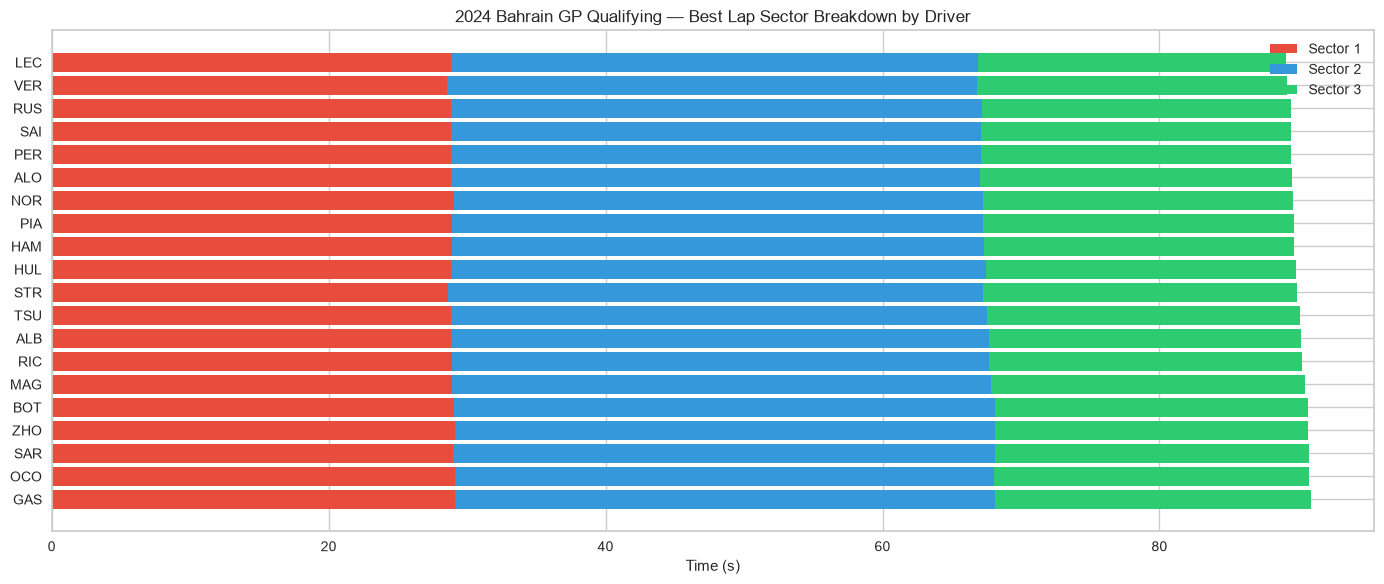

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

drivers = best_laps['Driver'].values
s1 = best_laps['S1'].values
s2 = best_laps['S2'].values
s3 = best_laps['S3'].values

ax.barh(drivers, s1, label='Sector 1', color='#e74c3c')
ax.barh(drivers, s2, left=s1, label='Sector 2', color='#3498db')
ax.barh(drivers, s3, left=s1+s2, label='Sector 3', color='#2ecc71')

ax.set_xlabel('Time (s)')
ax.set_title('2024 Bahrain GP Qualifying — Best Lap Sector Breakdown by Driver')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Speed-trap comparison

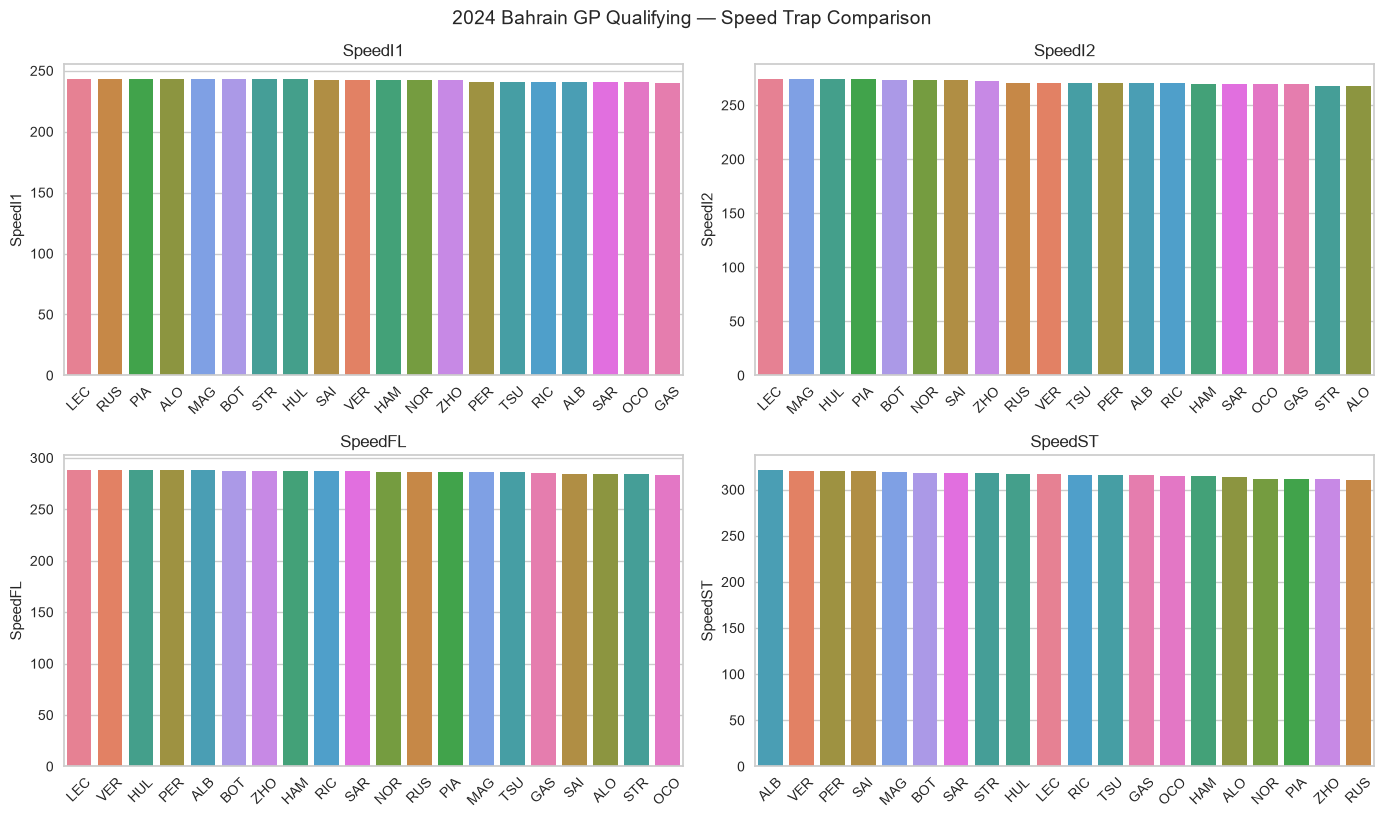

In [10]:
speed_cols = ['SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']

plt.figure(figsize=(14, 8))
for i, col in enumerate(speed_cols, 1):
    plt.subplot(2, 2, i)
    order = best_laps.sort_values(col, ascending=False)['Driver']
    sns.barplot(data=best_laps, x='Driver', y=col, order=order, hue='Driver', legend=False)
    plt.title(col)
    plt.xlabel('')
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle('2024 Bahrain GP Qualifying — Speed Trap Comparison', y=1.02, fontsize=14)
plt.show()

## 3. Lap-Time Prediction Model

In [11]:
from sklearn.preprocessing import LabelEncoder

# Start from clean laps, drop rows with any NaN in key columns
features = clean_laps[['Driver', 'Team', 'Compound', 'TyreLife', 'FreshTyre',
                        'Sector1Time', 'Sector2Time', 'Sector3Time',
                        'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
                        'LapTimeSeconds']].copy()

features = features.dropna()

# Convert timedeltas to seconds
features['S1'] = features['Sector1Time'].dt.total_seconds()
features['S2'] = features['Sector2Time'].dt.total_seconds()
features['S3'] = features['Sector3Time'].dt.total_seconds()
features = features.drop(columns=['Sector1Time', 'Sector2Time', 'Sector3Time'])

# Encode categoricals
le_driver = LabelEncoder()
le_team = LabelEncoder()
le_compound = LabelEncoder()

features['Driver'] = le_driver.fit_transform(features['Driver'])
features['Team'] = le_team.fit_transform(features['Team'])
features['Compound'] = le_compound.fit_transform(features['Compound'])
features['FreshTyre'] = features['FreshTyre'].astype(int)

print(features.shape)
print(features.dtypes)
print(features.head())

(85, 13)
Driver              int64
Team                int64
Compound            int64
TyreLife          float64
FreshTyre           int64
SpeedI1           float64
SpeedI2           float64
SpeedFL           float64
SpeedST           float64
LapTimeSeconds    float64
S1                float64
S2                float64
S3                float64
dtype: object
    Driver  Team  Compound  TyreLife  FreshTyre  SpeedI1  SpeedI2  SpeedFL  \
1       18     8         1       2.0          1    242.0    270.0    288.0   
4       18     8         1       5.0          0    241.0    271.0    286.0   
7       18     8         1       2.0          1    242.0    271.0    287.0   
12      18     8         1       2.0          1    241.0    272.0    286.0   
15      18     8         1       2.0          1    242.0    271.0    288.0   

    SpeedST  LapTimeSeconds      S1      S2      S3  
1     316.0          90.031  28.787  38.580  22.664  
4     317.0          90.160  28.822  38.767  22.571  
7     32

### Baseline XGBoost model

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

X = features.drop(columns=['LapTimeSeconds'])
y = features['LapTimeSeconds']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_pred), 4), "seconds")
print("R2:", round(r2_score(y_test, y_pred), 4))

MAE: 0.1368 seconds
R2: 0.9338


C:\Users\subha\AppData\Local\Temp\ipykernel_3944\1268856040.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

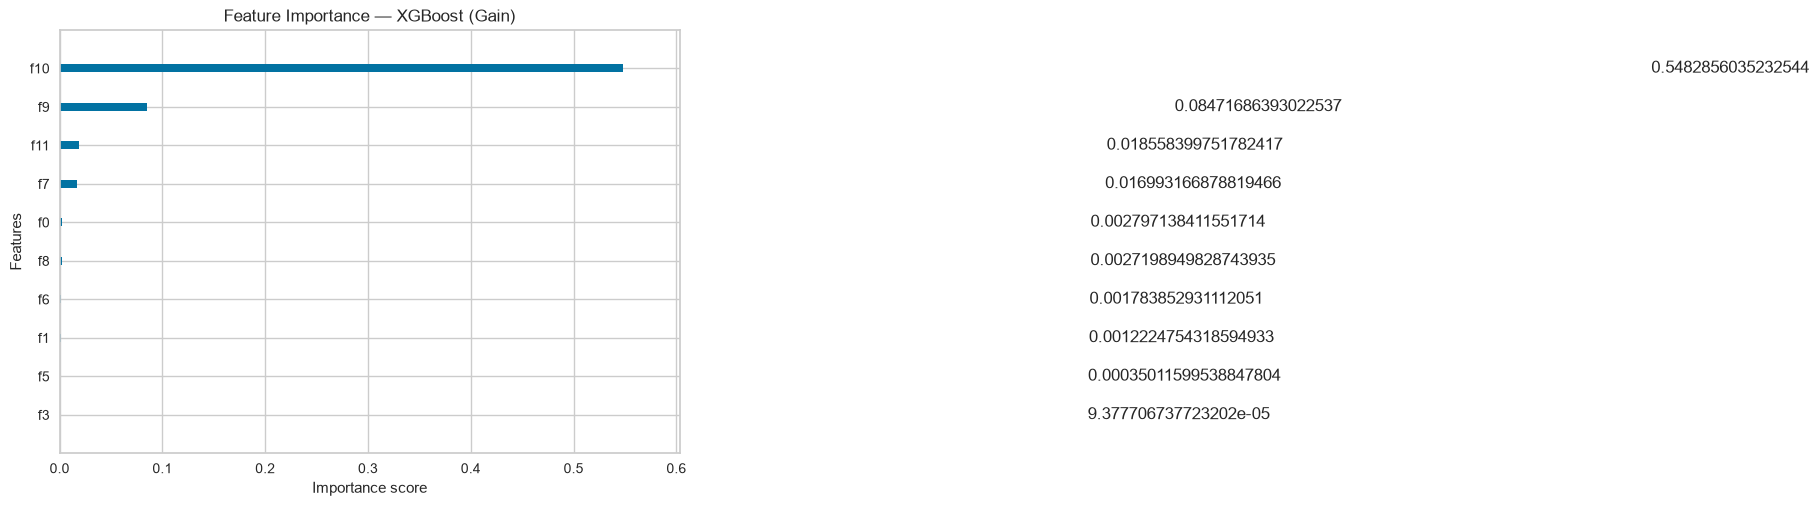

In [13]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=12, importance_type='gain')
plt.title('Feature Importance — XGBoost (Gain)')
plt.tight_layout()
plt.show()

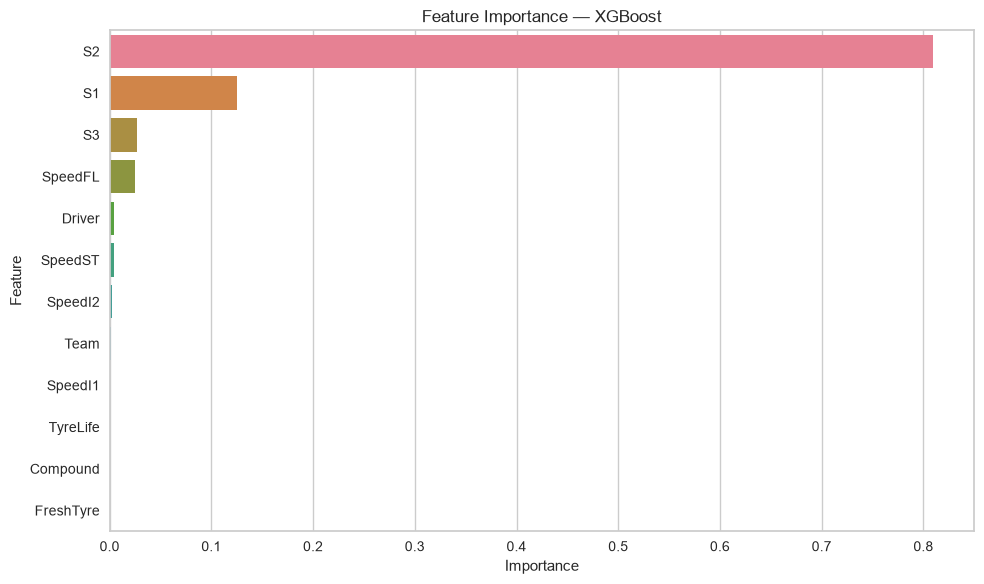

  Feature  Importance
       S2    0.809252
       S1    0.125039
       S3    0.027392
  SpeedFL    0.025081
   Driver    0.004128
  SpeedST    0.004014
  SpeedI2    0.002633
     Team    0.001804
  SpeedI1    0.000517
 TyreLife    0.000138
 Compound    0.000000
FreshTyre    0.000000


In [14]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', legend=False)
plt.title('Feature Importance — XGBoost')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

### Model without sector-time features

In [15]:
X_no_sectors = features.drop(columns=['LapTimeSeconds', 'S1', 'S2', 'S3'])
y = features['LapTimeSeconds']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_sectors, y, test_size=0.2, random_state=42)

model2 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("MAE:", round(mean_absolute_error(y_test2, y_pred2), 4), "seconds")
print("R2:", round(r2_score(y_test2, y_pred2), 4))

MAE: 0.3342 seconds
R2: 0.7122


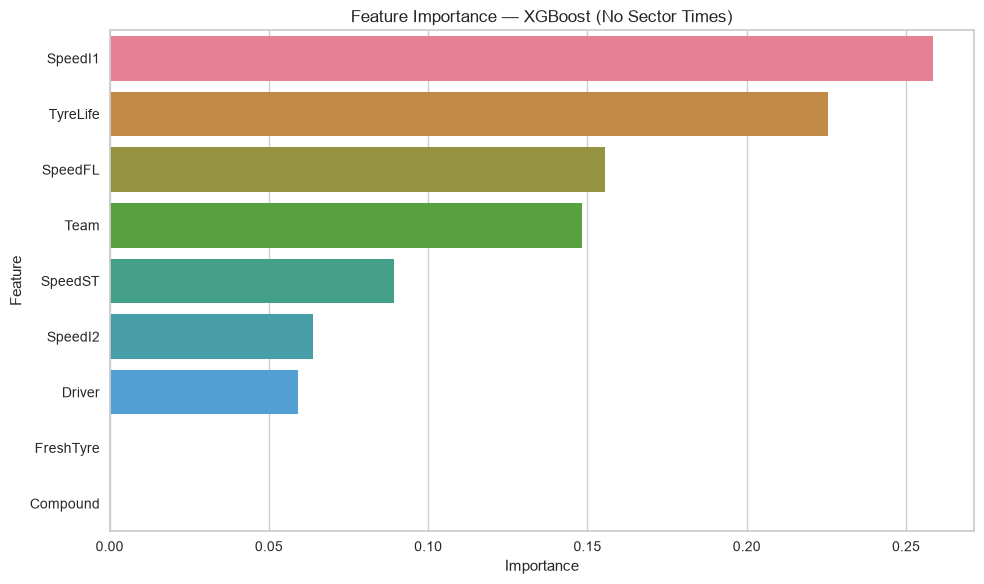

  Feature  Importance
  SpeedI1    0.258409
 TyreLife    0.225443
  SpeedFL    0.155402
     Team    0.148276
  SpeedST    0.089390
  SpeedI2    0.063875
   Driver    0.059205
FreshTyre    0.000000
 Compound    0.000000


In [16]:
importance_df2 = pd.DataFrame({
    'Feature': X_no_sectors.columns,
    'Importance': model2.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df2, x='Importance', y='Feature', hue='Feature', legend=False)
plt.title('Feature Importance — XGBoost (No Sector Times)')
plt.tight_layout()
plt.show()

print(importance_df2.to_string(index=False))

### Prediction comparison

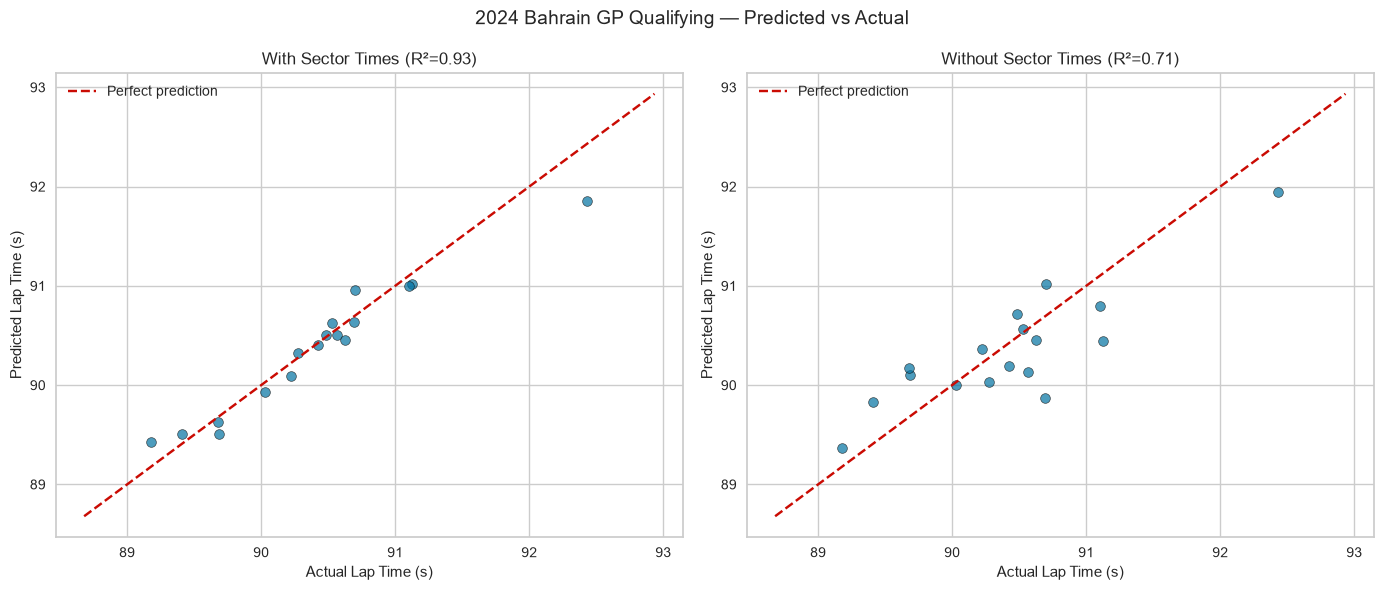

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_t, y_p, title in zip(
    axes,
    [y_test, y_test2],
    [y_pred, y_pred2],
    ['With Sector Times (R²=0.93)', 'Without Sector Times (R²=0.71)']
):
    ax.scatter(y_t, y_p, alpha=0.7, edgecolors='k', linewidths=0.5)
    min_val = min(y_t.min(), y_p.min()) - 0.5
    max_val = max(y_t.max(), y_p.max()) + 0.5
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    ax.set_xlabel('Actual Lap Time (s)')
    ax.set_ylabel('Predicted Lap Time (s)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('2024 Bahrain GP Qualifying — Predicted vs Actual', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Combining Qualifying and Race Data

In [18]:
race = fastf1.get_session(2024, 'Bahrain', 'R')
race.load()

race_laps = race.laps.pick_accurate().copy()
race_laps['LapTimeSeconds'] = race_laps['LapTime'].dt.total_seconds()
race_laps['S1'] = race_laps['Sector1Time'].dt.total_seconds()
race_laps['S2'] = race_laps['Sector2Time'].dt.total_seconds()
race_laps['S3'] = race_laps['Sector3Time'].dt.total_seconds()
race_laps['SessionType'] = 'R'
clean_laps['SessionType'] = 'Q'

print("Race laps:", len(race_laps))
print("Compound distribution:")
print(race_laps['Compound'].value_counts())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Race laps: 1024
Compound distribution:
Compound
HARD    731
SOFT    293
Name: count, dtype: int64


In [19]:
clean_laps['S1'] = clean_laps['Sector1Time'].dt.total_seconds()
clean_laps['S2'] = clean_laps['Sector2Time'].dt.total_seconds()
clean_laps['S3'] = clean_laps['Sector3Time'].dt.total_seconds()

cols = ['Driver', 'Team', 'Compound', 'TyreLife', 'FreshTyre',
        'S1', 'S2', 'S3',
        'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
        'LapTimeSeconds', 'SessionType']

combined = pd.concat([clean_laps[cols], race_laps[cols]], ignore_index=True)
combined = combined.dropna()

print("Combined shape:", combined.shape)
print("Session breakdown:")
print(combined['SessionType'].value_counts())
print("\nCompound breakdown:")
print(combined['Compound'].value_counts())

Combined shape: (1109, 14)
Session breakdown:
SessionType
R    1024
Q      85
Name: count, dtype: int64

Compound breakdown:
Compound
HARD      731
SOFT      374
MEDIUM      4
Name: count, dtype: int64


### Combined-data model

In [20]:
from sklearn.preprocessing import LabelEncoder

combined_features = combined.copy()

le_driver = LabelEncoder()
le_team = LabelEncoder()
le_compound = LabelEncoder()
le_session = LabelEncoder()

combined_features['Driver'] = le_driver.fit_transform(combined_features['Driver'])
combined_features['Team'] = le_team.fit_transform(combined_features['Team'])
combined_features['Compound'] = le_compound.fit_transform(combined_features['Compound'])
combined_features['SessionType'] = le_session.fit_transform(combined_features['SessionType'])
combined_features['FreshTyre'] = combined_features['FreshTyre'].astype(int)

X_combined = combined_features.drop(columns=['LapTimeSeconds'])
y_combined = combined_features['LapTimeSeconds']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42)

model3 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("MAE:", round(mean_absolute_error(y_test3, y_pred3), 4), "seconds")
print("R2:", round(r2_score(y_test3, y_pred3), 4))

MAE: 0.069 seconds
R2: 0.9978


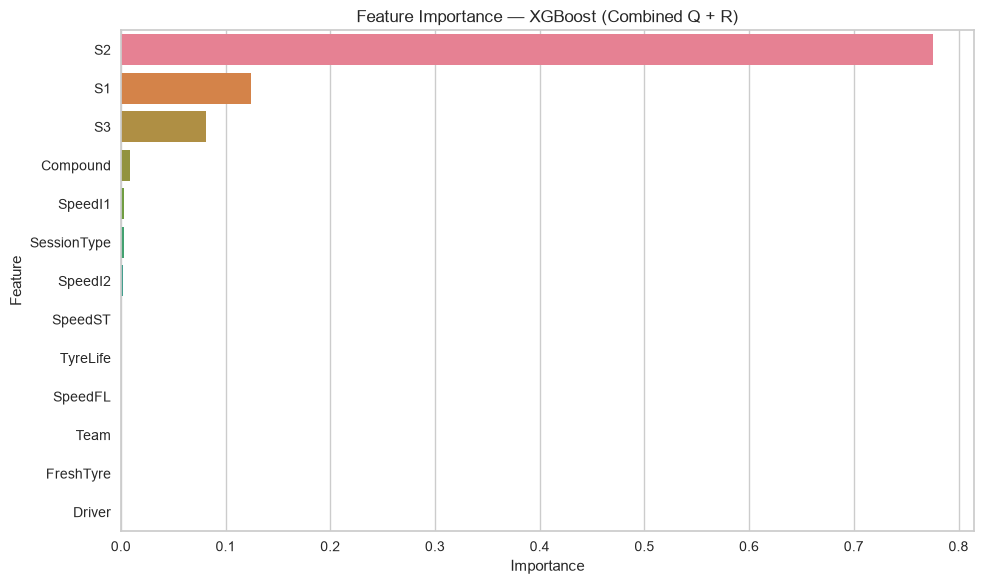

    Feature  Importance
         S2    0.775973
         S1    0.123985
         S3    0.081060
   Compound    0.009086
    SpeedI1    0.003388
SessionType    0.003122
    SpeedI2    0.001862
    SpeedST    0.000436
   TyreLife    0.000323
    SpeedFL    0.000305
       Team    0.000260
  FreshTyre    0.000123
     Driver    0.000078


In [21]:
importance_df3 = pd.DataFrame({
    'Feature': X_combined.columns,
    'Importance': model3.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df3, x='Importance', y='Feature', hue='Feature', legend=False)
plt.title('Feature Importance — XGBoost (Combined Q + R)')
plt.tight_layout()
plt.show()

print(importance_df3.to_string(index=False))

## 5. Expanding to Multiple Circuits

In [22]:
sessions_to_load = [
    (2024, 'Monaco', 'Q'),
    (2024, 'Monaco', 'R'),
    (2024, 'Monza', 'Q'),
    (2024, 'Monza', 'R'),
    (2024, 'Silverstone', 'Q'),
    (2024, 'Silverstone', 'R'),
]

all_laps = [combined]  # already have Bahrain Q + R

for year, gp, session_type in sessions_to_load:
    session = fastf1.get_session(year, gp, session_type)
    session.load()
    laps = session.laps.pick_accurate().copy()
    laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
    laps['S1'] = laps['Sector1Time'].dt.total_seconds()
    laps['S2'] = laps['Sector2Time'].dt.total_seconds()
    laps['S3'] = laps['Sector3Time'].dt.total_seconds()
    laps['SessionType'] = session_type
    all_laps.append(laps[cols])

full_data = pd.concat(all_laps, ignore_index=True)
full_data = full_data.dropna()

print("Full dataset shape:", full_data.shape)
print("\nCompound breakdown:")
print(full_data['Compound'].value_counts())

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data

Full dataset shape: (4583, 14)

Compound breakdown:
Compound
HARD            2220
MEDIUM          1100
SOFT            1028
INTERMEDIATE     235
Name: count, dtype: int64


### Four-circuit XGBoost model

In [23]:
full_features = full_data.copy()

le_driver = LabelEncoder()
le_team = LabelEncoder()
le_compound = LabelEncoder()
le_session = LabelEncoder()

full_features['Driver'] = le_driver.fit_transform(full_features['Driver'])
full_features['Team'] = le_team.fit_transform(full_features['Team'])
full_features['Compound'] = le_compound.fit_transform(full_features['Compound'])
full_features['SessionType'] = le_session.fit_transform(full_features['SessionType'])
full_features['FreshTyre'] = full_features['FreshTyre'].astype(int)

X_full = full_features.drop(columns=['LapTimeSeconds'])
y_full = full_features['LapTimeSeconds']

X_train4, X_test4, y_train4, y_test4 = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

model4 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
model4.fit(X_train4, y_train4)

y_pred4 = model4.predict(X_test4)

print("MAE:", round(mean_absolute_error(y_test4, y_pred4), 4), "seconds")
print("R2:", round(r2_score(y_test4, y_pred4), 4))

MAE: 0.2208 seconds
R2: 0.9948


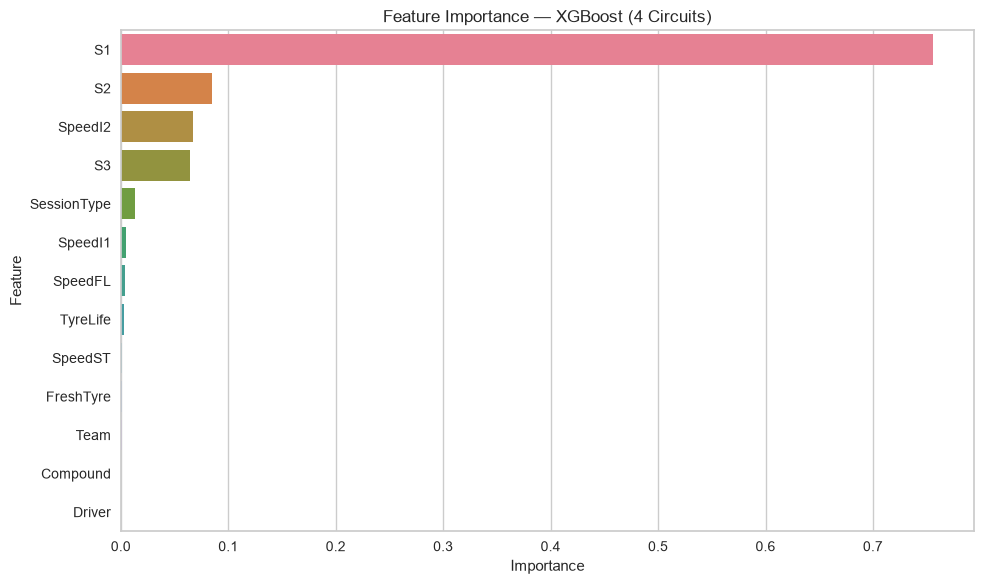

    Feature  Importance
         S1    0.756236
         S2    0.084969
    SpeedI2    0.067107
         S3    0.064131
SessionType    0.012899
    SpeedI1    0.004977
    SpeedFL    0.003748
   TyreLife    0.002922
    SpeedST    0.000920
  FreshTyre    0.000821
       Team    0.000720
   Compound    0.000324
     Driver    0.000226


In [24]:
importance_df4 = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': model4.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df4, x='Importance', y='Feature', hue='Feature', legend=False)
plt.title('Feature Importance — XGBoost (4 Circuits)')
plt.tight_layout()
plt.show()

print(importance_df4.to_string(index=False))

## 6. Saving the Model and Dataset

In [25]:
import joblib

joblib.dump(model4, 'f1_xgb_model.pkl')
full_data.to_csv('f1_full_data.csv', index=False)

print("Model and dataset saved.")

Model and dataset saved.


## 7. Tyre Degradation Analysis

### Filtering race laps for degradation analysis

In [26]:
race_data = full_data[full_data['SessionType'] == 'R'].copy()
race_data = race_data[race_data['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])].copy()

race_data['MedianLap'] = race_data.groupby('Driver')['LapTimeSeconds'].transform('median')
race_data = race_data[race_data['LapTimeSeconds'] <= race_data['MedianLap'] * 1.07].copy()

print("Race laps after filtering:", len(race_data))
print(race_data['Compound'].value_counts())

Race laps after filtering: 2676
Compound
HARD      1661
MEDIUM     791
SOFT       224
Name: count, dtype: int64


### Overall tyre degradation

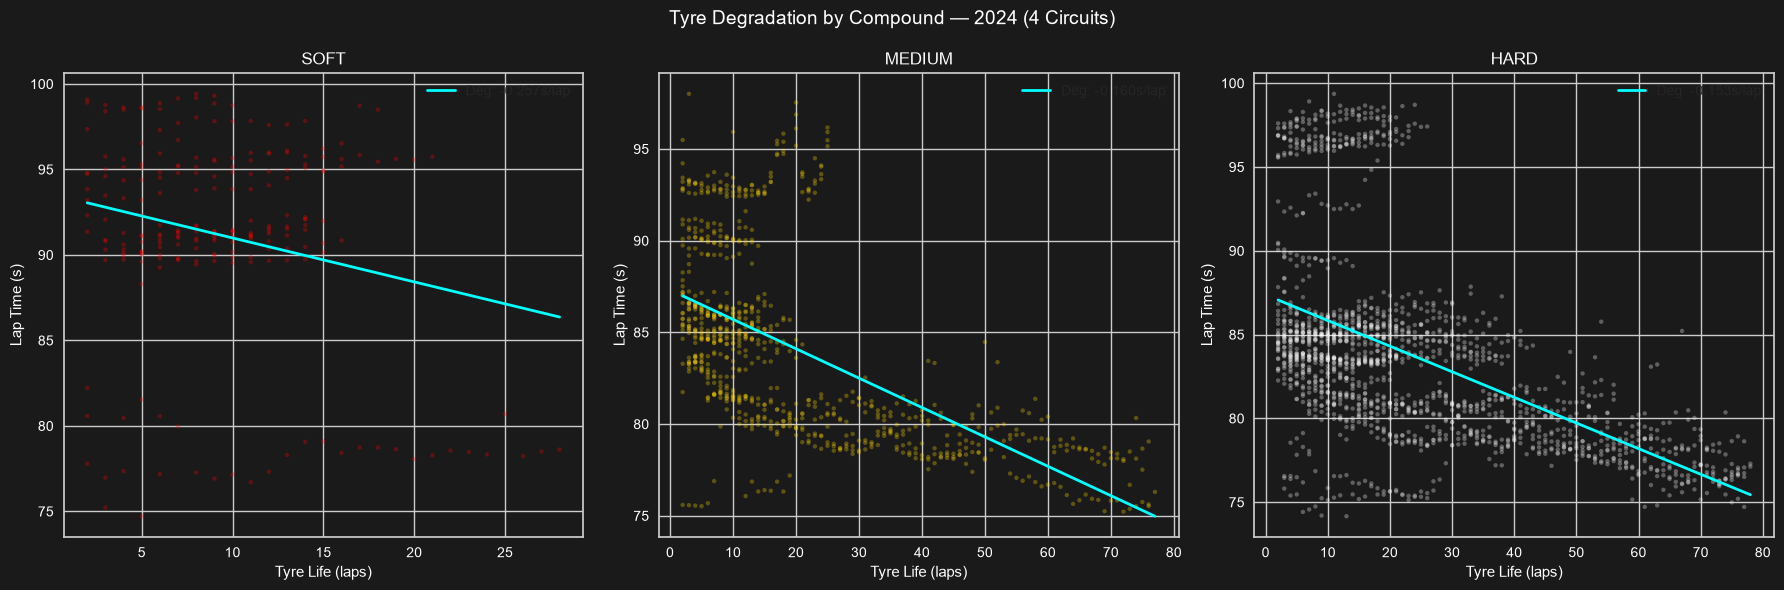

In [27]:
from numpy.polynomial import polynomial as P
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
compounds = ['SOFT', 'MEDIUM', 'HARD']
colors = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'white'}

for ax, compound in zip(axes, compounds):
    data = race_data[race_data['Compound'] == compound]

    ax.scatter(data['TyreLife'], data['LapTimeSeconds'],
               alpha=0.3, s=10, color=colors[compound], edgecolors='none')

    # Fit a linear trend line
    z = np.polyfit(data['TyreLife'], data['LapTimeSeconds'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data['TyreLife'].min(), data['TyreLife'].max(), 100)
    ax.plot(x_line, p(x_line), color='cyan', linewidth=2, label=f'Deg: {z[0]:.3f}s/lap')

    ax.set_title(f'{compound}', color=colors[compound] if compound != 'WHITE' else 'black')
    ax.set_xlabel('Tyre Life (laps)')
    ax.set_ylabel('Lap Time (s)')
    ax.legend()
    ax.set_facecolor('#1a1a1a')

fig.patch.set_facecolor('#1a1a1a')
for ax in axes:
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

plt.suptitle('Tyre Degradation by Compound — 2024 (4 Circuits)', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Tyre Degradation by Circuit

### Circuit-level tyre degradation

In [28]:
# Rebuild race_data with circuit labels
circuit_sessions = [
    (2024, 'Bahrain', 'R'),
    (2024, 'Monaco', 'R'),
    (2024, 'Monza', 'R'),
    (2024, 'Silverstone', 'R'),
]

race_chunks = []
for year, gp, st in circuit_sessions:
    s = fastf1.get_session(year, gp, st)
    s.load()
    laps = s.laps.pick_accurate().copy()
    laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
    laps['S1'] = laps['Sector1Time'].dt.total_seconds()
    laps['S2'] = laps['Sector2Time'].dt.total_seconds()
    laps['S3'] = laps['Sector3Time'].dt.total_seconds()
    laps['SessionType'] = st
    laps['Circuit'] = gp
    race_chunks.append(laps)

race_data2 = pd.concat(race_chunks, ignore_index=True)
race_data2 = race_data2[race_data2['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])].copy()
race_data2['MedianLap'] = race_data2.groupby(['Driver', 'Circuit'])['LapTimeSeconds'].transform('median')
race_data2 = race_data2[race_data2['LapTimeSeconds'] <= race_data2['MedianLap'] * 1.07].copy()
race_data2 = race_data2.dropna(subset=['LapTimeSeconds', 'TyreLife', 'Compound'])

print(race_data2['Circuit'].value_counts())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Monaco Grand Prix - Race

Circuit
Monaco         1170
Bahrain        1024
Monza           927
Silverstone     634
Name: count, dtype: int64


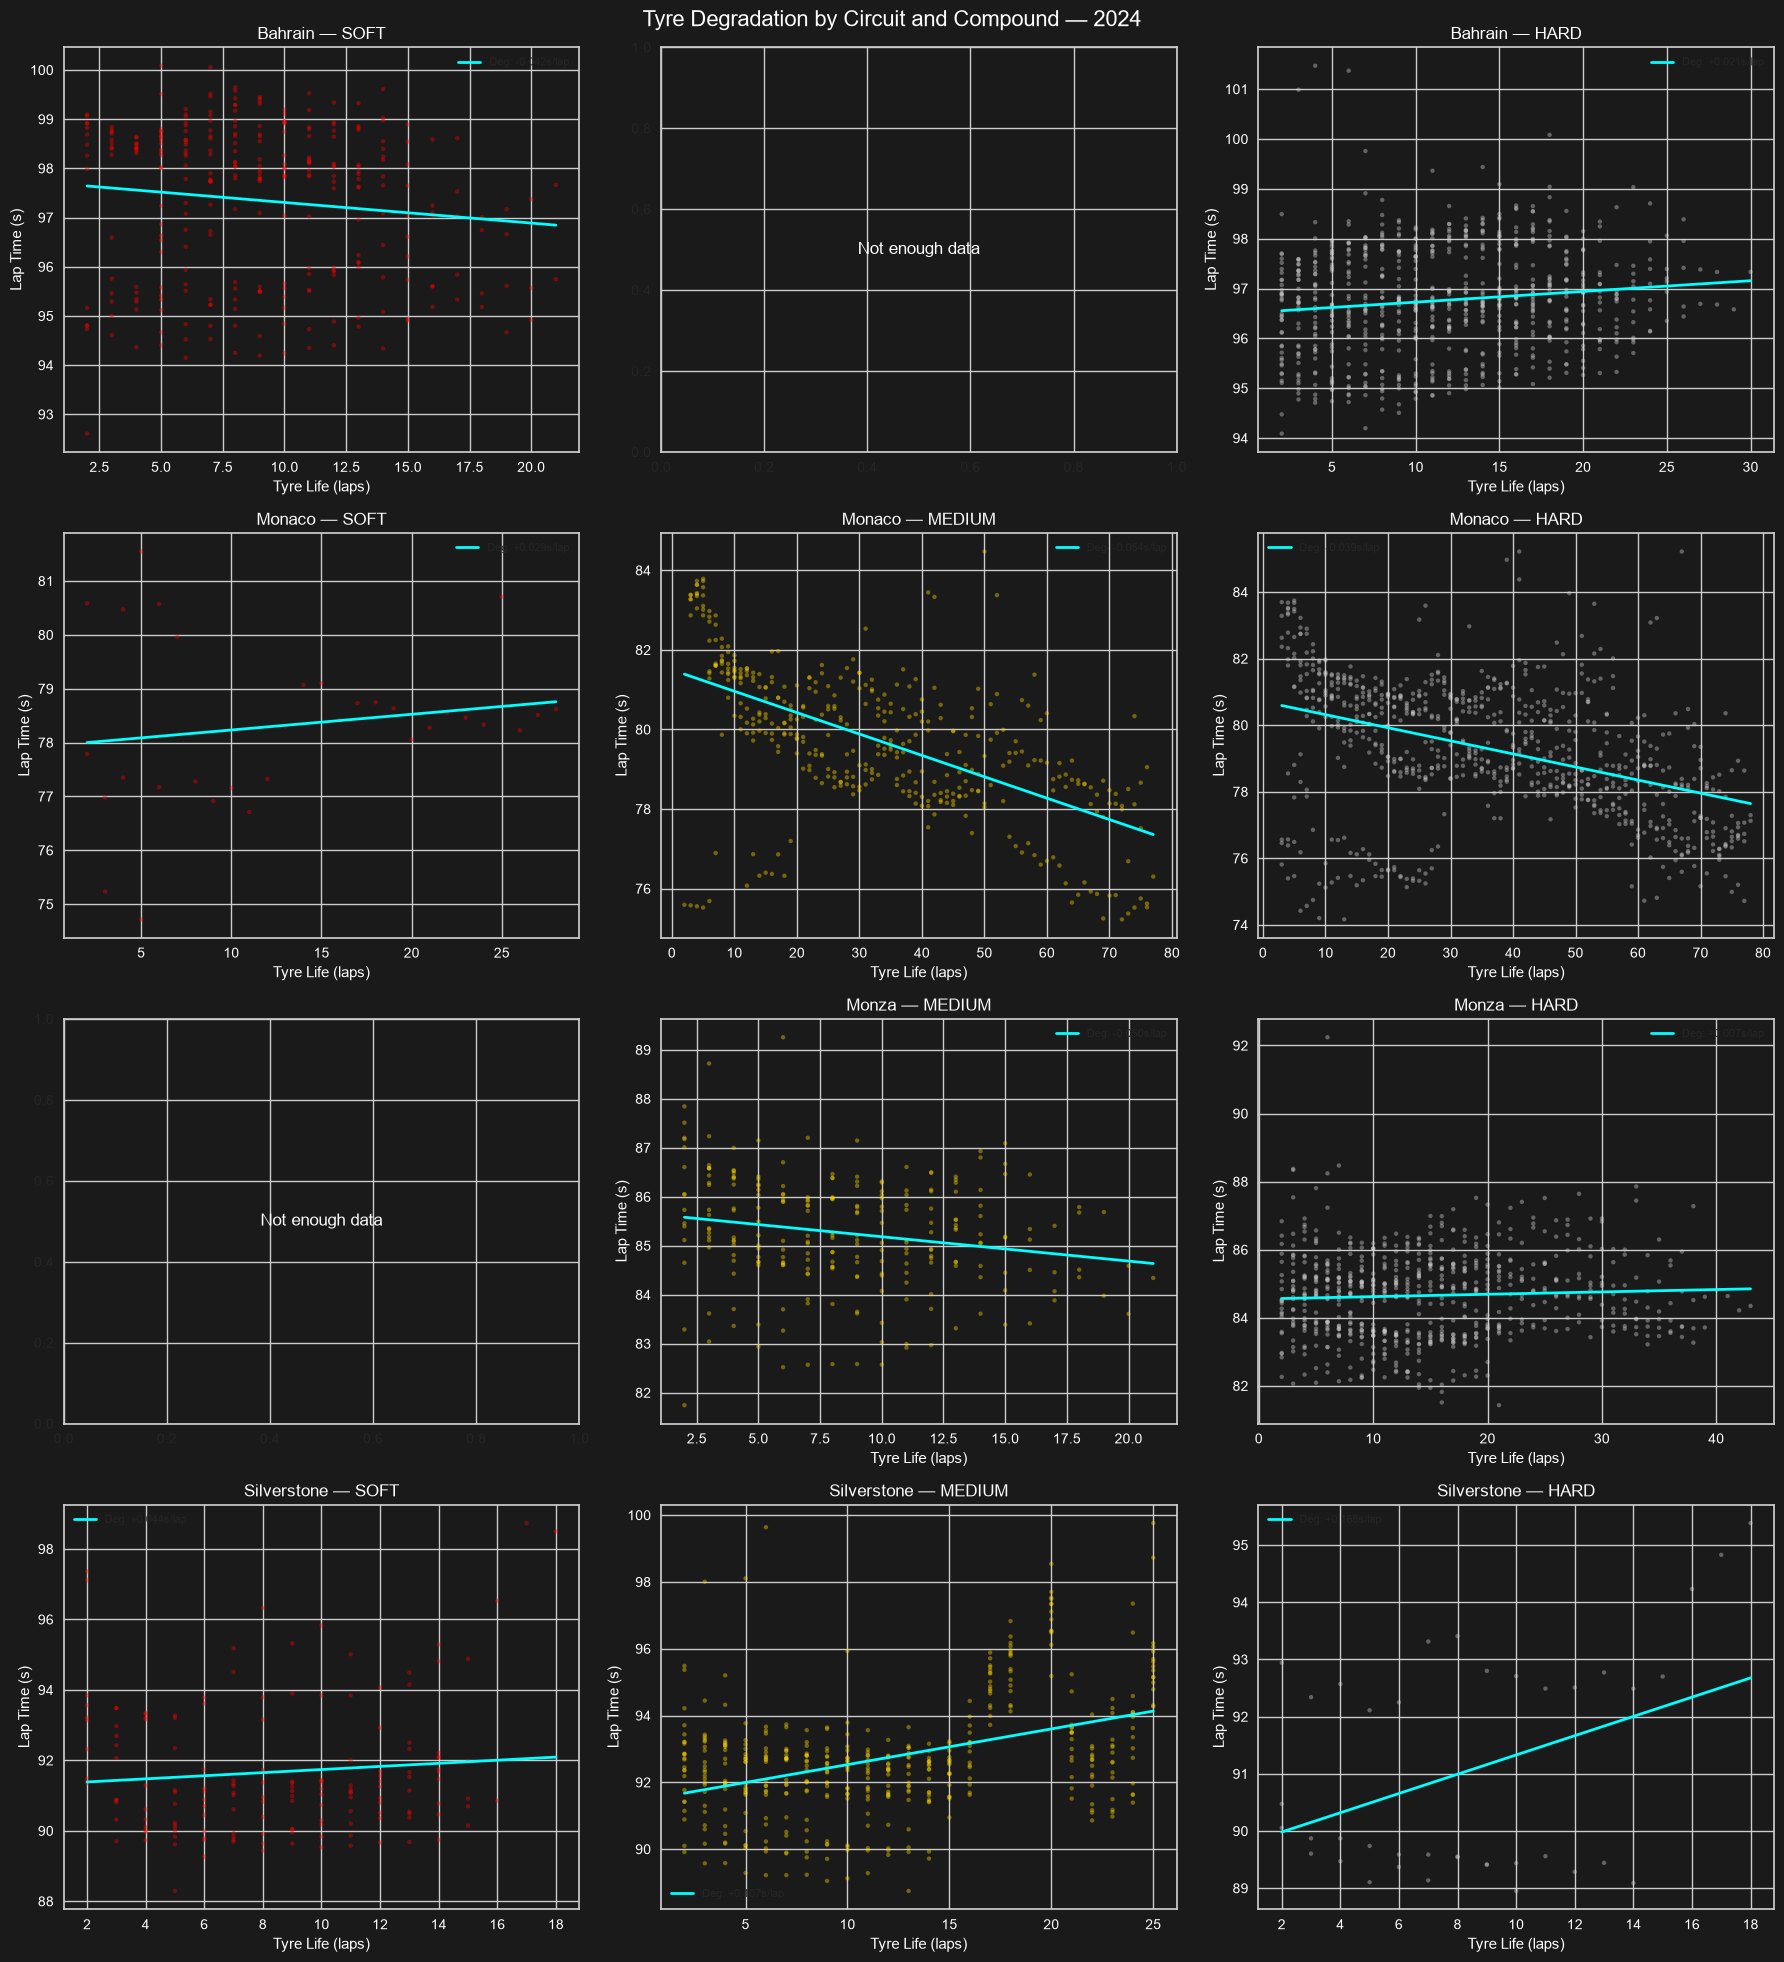

In [29]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
compounds = ['SOFT', 'MEDIUM', 'HARD']
circuits = ['Bahrain', 'Monaco', 'Monza', 'Silverstone']
colors = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'lightgray'}

for row, circuit in enumerate(circuits):
    for col, compound in enumerate(compounds):
        ax = axes[row][col]
        data = race_data2[(race_data2['Circuit'] == circuit) &
                          (race_data2['Compound'] == compound)]

        if len(data) < 5:
            ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center',
                    transform=ax.transAxes, color='white')
            ax.set_facecolor('#1a1a1a')
            continue

        ax.scatter(data['TyreLife'], data['LapTimeSeconds'],
                   alpha=0.4, s=10, color=colors[compound], edgecolors='none')

        z = np.polyfit(data['TyreLife'], data['LapTimeSeconds'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data['TyreLife'].min(), data['TyreLife'].max(), 100)
        ax.plot(x_line, p(x_line), color='cyan', linewidth=2,
                label=f'Deg: {z[0]:+.3f}s/lap')

        ax.set_title(f'{circuit} — {compound}', color='white')
        ax.set_xlabel('Tyre Life (laps)', color='white')
        ax.set_ylabel('Lap Time (s)', color='white')
        ax.legend(fontsize=8)
        ax.set_facecolor('#1a1a1a')
        ax.tick_params(colors='white')

fig.patch.set_facecolor('#1a1a1a')
plt.suptitle('Tyre Degradation by Circuit and Compound — 2024', color='white', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Track Evolution Normalization

### Normalizing for track evolution

In [30]:
# Calculate track evolution baseline per circuit (median lap time across all drivers per lap number)
race_data2['LapNumber'] = race_data2.groupby(['Circuit', 'Driver']).cumcount() + 1

track_evo = race_data2.groupby(['Circuit', 'LapNumber'])['LapTimeSeconds'].median().reset_index()
track_evo.columns = ['Circuit', 'LapNumber', 'TrackMedian']

race_data2 = race_data2.merge(track_evo, on=['Circuit', 'LapNumber'], how='left')
race_data2['NormalizedLapTime'] = race_data2['LapTimeSeconds'] - race_data2['TrackMedian']

print(race_data2[['Circuit', 'Driver', 'TyreLife', 'LapTimeSeconds', 'NormalizedLapTime']].head(10))

   Circuit Driver  TyreLife  LapTimeSeconds  NormalizedLapTime
0  Bahrain    VER       5.0          96.296            -1.9700
1  Bahrain    VER       6.0          96.753            -1.5980
2  Bahrain    VER       7.0          96.647            -1.6515
3  Bahrain    VER       8.0          97.173            -1.2565
4  Bahrain    VER       9.0          97.092            -1.1800
5  Bahrain    VER      10.0          97.038            -1.4710
6  Bahrain    VER      11.0          97.024            -1.3430
7  Bahrain    VER      12.0          97.229            -1.2330
8  Bahrain    VER      13.0          96.960            -1.0265
9  Bahrain    VER      14.0          97.085            -0.9190


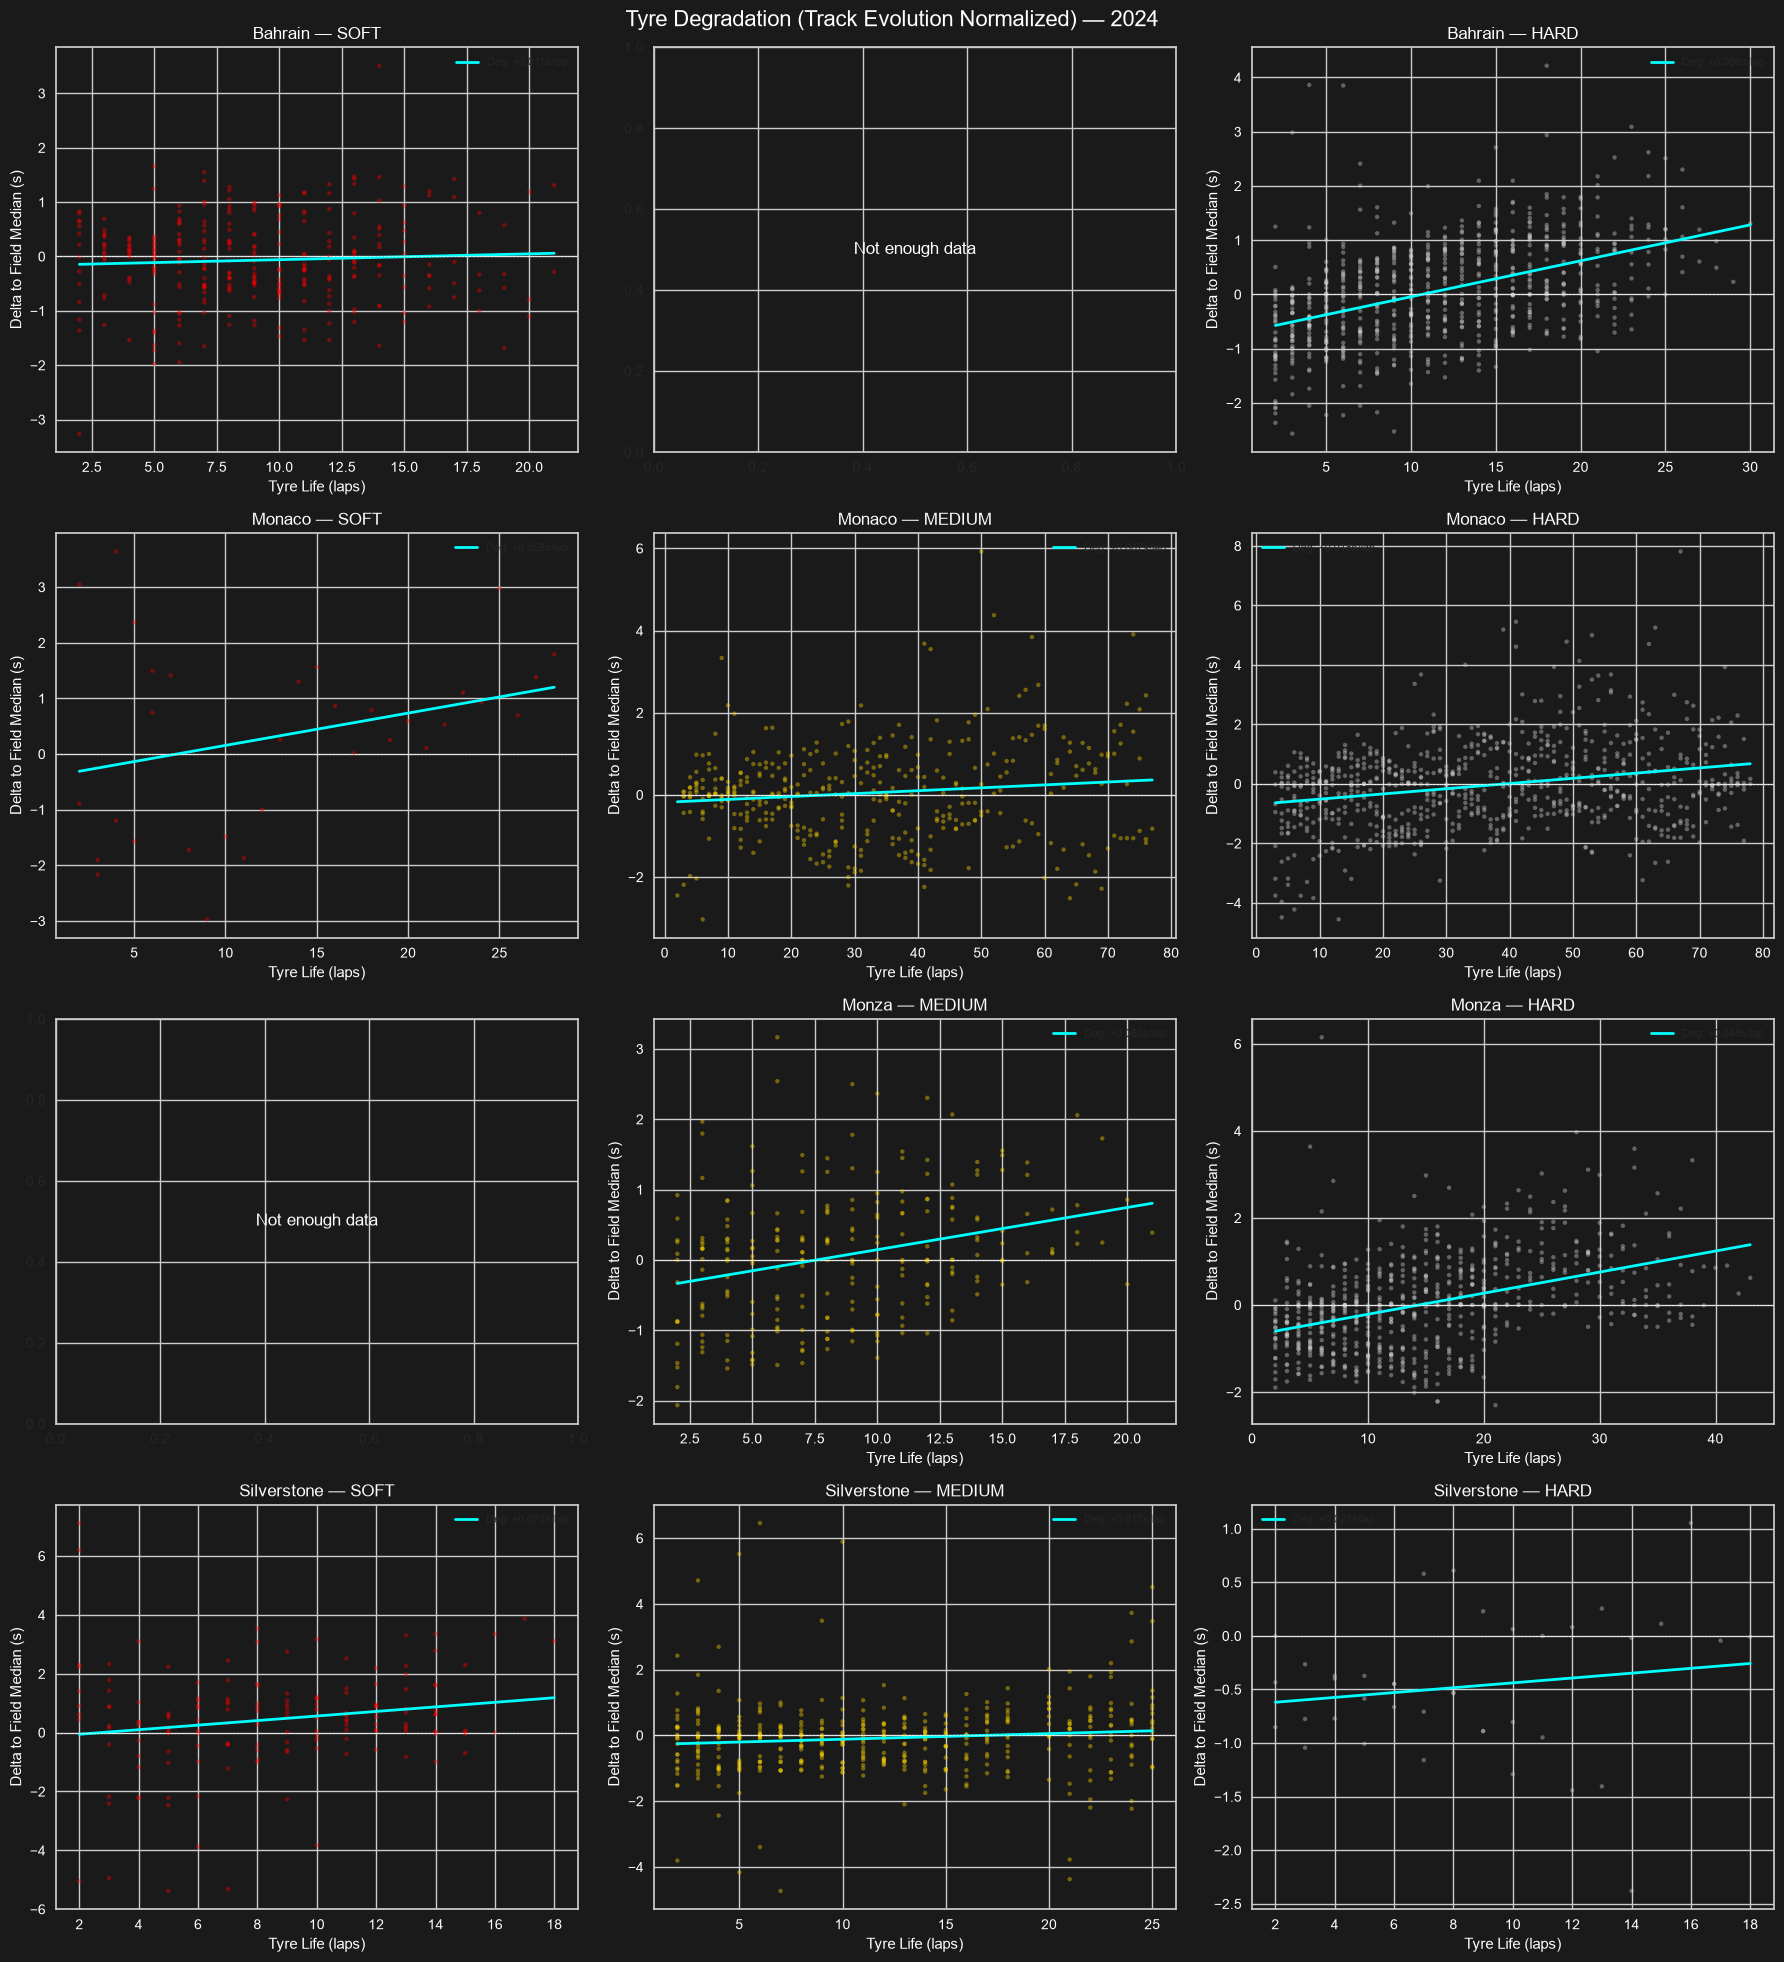

In [31]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
compounds = ['SOFT', 'MEDIUM', 'HARD']
circuits = ['Bahrain', 'Monaco', 'Monza', 'Silverstone']
colors = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'lightgray'}

for row, circuit in enumerate(circuits):
    for col, compound in enumerate(compounds):
        ax = axes[row][col]
        data = race_data2[(race_data2['Circuit'] == circuit) &
                          (race_data2['Compound'] == compound)]

        if len(data) < 5:
            ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center',
                    transform=ax.transAxes, color='white')
            ax.set_facecolor('#1a1a1a')
            continue

        ax.scatter(data['TyreLife'], data['NormalizedLapTime'],
                   alpha=0.4, s=10, color=colors[compound], edgecolors='none')

        z = np.polyfit(data['TyreLife'], data['NormalizedLapTime'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data['TyreLife'].min(), data['TyreLife'].max(), 100)
        ax.plot(x_line, p(x_line), color='cyan', linewidth=2,
                label=f'Deg: {z[0]:+.3f}s/lap')

        ax.axhline(0, color='white', linewidth=0.5, linestyle='--')
        ax.set_title(f'{circuit} — {compound}', color='white')
        ax.set_xlabel('Tyre Life (laps)', color='white')
        ax.set_ylabel('Delta to Field Median (s)', color='white')
        ax.legend(fontsize=8)
        ax.set_facecolor('#1a1a1a')
        ax.tick_params(colors='white')

fig.patch.set_facecolor('#1a1a1a')
plt.suptitle('Tyre Degradation (Track Evolution Normalized) — 2024', color='white', fontsize=16)
plt.tight_layout()
plt.show()

## 10. Driver Consistency Analysis

### Consistency metrics

In [32]:
consistency = race_data2.groupby(['Driver', 'Circuit']).agg(
    AvgLapTime=('LapTimeSeconds', 'mean'),
    StdLapTime=('LapTimeSeconds', 'std'),
    LapCount=('LapTimeSeconds', 'count')
).reset_index()

# Coefficient of variation — std as % of mean, normalizes across circuits
consistency['CV'] = (consistency['StdLapTime'] / consistency['AvgLapTime']) * 100

# Only keep drivers with enough laps to be meaningful
consistency = consistency[consistency['LapCount'] >= 10]

print(consistency.sort_values('CV').head(10))

   Driver  Circuit  AvgLapTime  StdLapTime  LapCount        CV
46    RIC    Monza   85.238500    0.612554        50  0.718636
25    LEC    Monza   83.949360    0.629429        50  0.749773
71    ZHO  Bahrain   97.407294    0.875354        51  0.898653
2     ALB    Monza   85.174980    0.768067        50  0.901751
48    RUS  Bahrain   96.474135    0.886020        52  0.918402
54    SAI    Monza   84.236080    0.783035        50  0.929572
63    TSU  Bahrain   97.485510    0.915248        51  0.938855
59    STR  Bahrain   97.124365    0.925715        52  0.953123
34    OCO  Bahrain   97.810725    0.934607        51  0.955526
35    OCO    Monza   85.765041    0.826412        49  0.963577


### Consistency heatmap

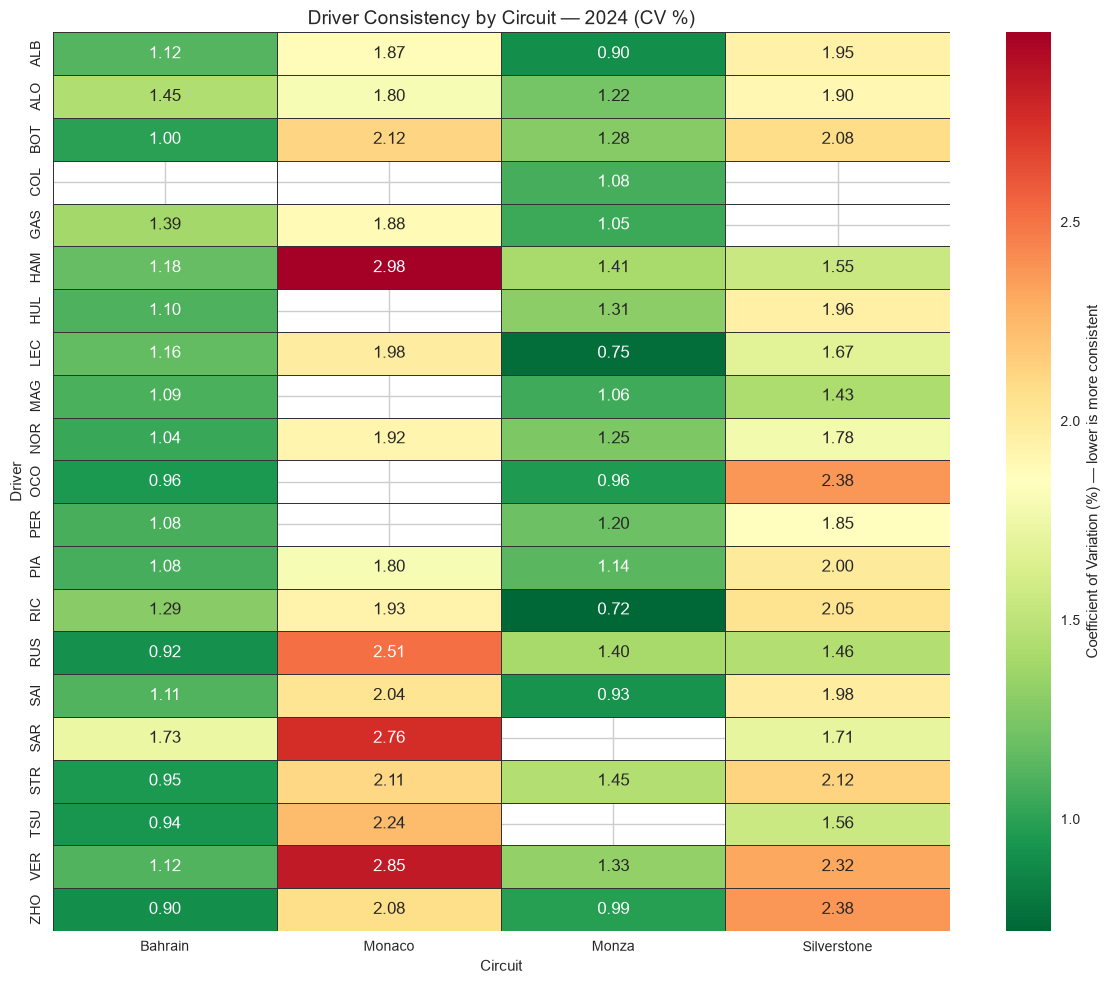

In [33]:
pivot = consistency.pivot_table(index='Driver', columns='Circuit', values='CV')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='#333333',
            cbar_kws={'label': 'Coefficient of Variation (%) — lower is more consistent'})
plt.title('Driver Consistency by Circuit — 2024 (CV %)', fontsize=14)
plt.xlabel('Circuit')
plt.ylabel('Driver')
plt.tight_layout()
plt.show()

### Overall driver consistency

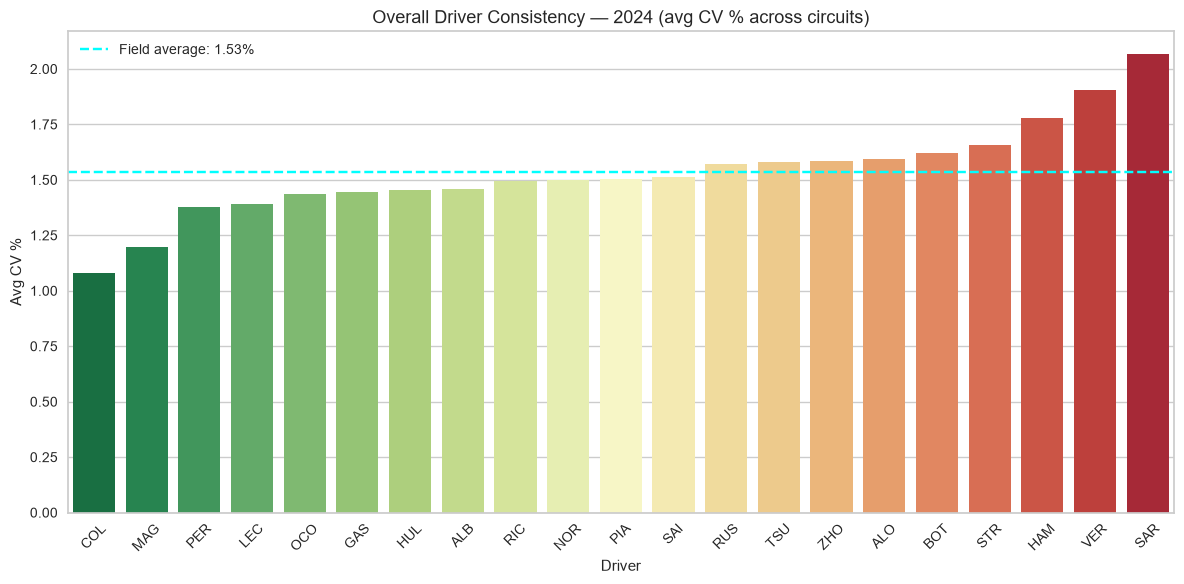

Most consistent: COL 1.078
Least consistent: SAR 2.065


In [34]:
overall_consistency = consistency.groupby('Driver')['CV'].mean().sort_values()

plt.figure(figsize=(12, 6))
sns.barplot(x=overall_consistency.index, y=overall_consistency.values,
            hue=overall_consistency.index, legend=False,
            palette='RdYlGn_r' )
plt.axhline(overall_consistency.mean(), color='cyan', linestyle='--',
            label=f'Field average: {overall_consistency.mean():.2f}%')
plt.title('Overall Driver Consistency — 2024 (avg CV % across circuits)', fontsize=13)
plt.xlabel('Driver')
plt.ylabel('Avg CV %')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("Most consistent:", overall_consistency.index[0], round(overall_consistency.iloc[0], 3))
print("Least consistent:", overall_comparison := overall_consistency.index[-1], round(overall_consistency.iloc[-1], 3))